In [23]:
image_set = "utzap"
text_set = "nemotron"
mode = "test"

In [24]:
from sklearn.metrics.pairwise import cosine_similarity
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import os
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [25]:
combined_set = image_set + "+" + text_set

In [26]:
# Load model and processor
# model = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip")
# processor = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
if mode == "test":
    with open(f"../generate_test_set/{combined_set}/test_indices.json", "r") as f:
        test_indices = json.load(f)
    with open(f'../data_preparation/{image_set}/images_test.pkl', 'rb') as f:
        sampled_images = pickle.load(f)
    with open(f'../data_preparation/{text_set}/test_personas.json', 'r') as f:
        test_personas = json.load(f)[:len(test_indices)]
if mode == "val":
    with open(f"../generate_test_set/{combined_set}/val_indices.json", "r") as f:
        test_indices = json.load(f)
    with open(f'../data_preparation/{image_set}/images_val.pkl', 'rb') as f:
        sampled_images = pickle.load(f)
    with open(f'../data_preparation/{text_set}/validation_personas.json', 'r') as f:
        test_personas = json.load(f)[:len(test_indices)]

In [28]:
len(test_personas), len(sampled_images), len(test_indices)

(43, 4096, 43)

In [29]:
text_inputs = processor(text=test_personas, return_tensors="pt", padding=True, truncation=True, max_length=77)
text_features = model.get_text_features(**text_inputs)

In [30]:
image_embeddings = []

for image in tqdm(sampled_images):
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
    image_embeddings.append(image_features)

  0%|          | 0/4096 [00:00<?, ?it/s]

In [31]:
image_embeddings_tensor = torch.cat(image_embeddings)

In [32]:
rank_list = []
K = []
for i in range(len(text_features)):
    scores = cosine_similarity(
        image_embeddings_tensor.detach().cpu().numpy(),
        text_features[i].unsqueeze(0).detach().cpu().numpy()
    )
    sorted_indices = np.argsort(scores, axis=0).squeeze()[::-1]
    K.append(sorted_indices.tolist())
    n = sorted_indices.tolist().index(test_indices[i])
    rank_list.append(n)

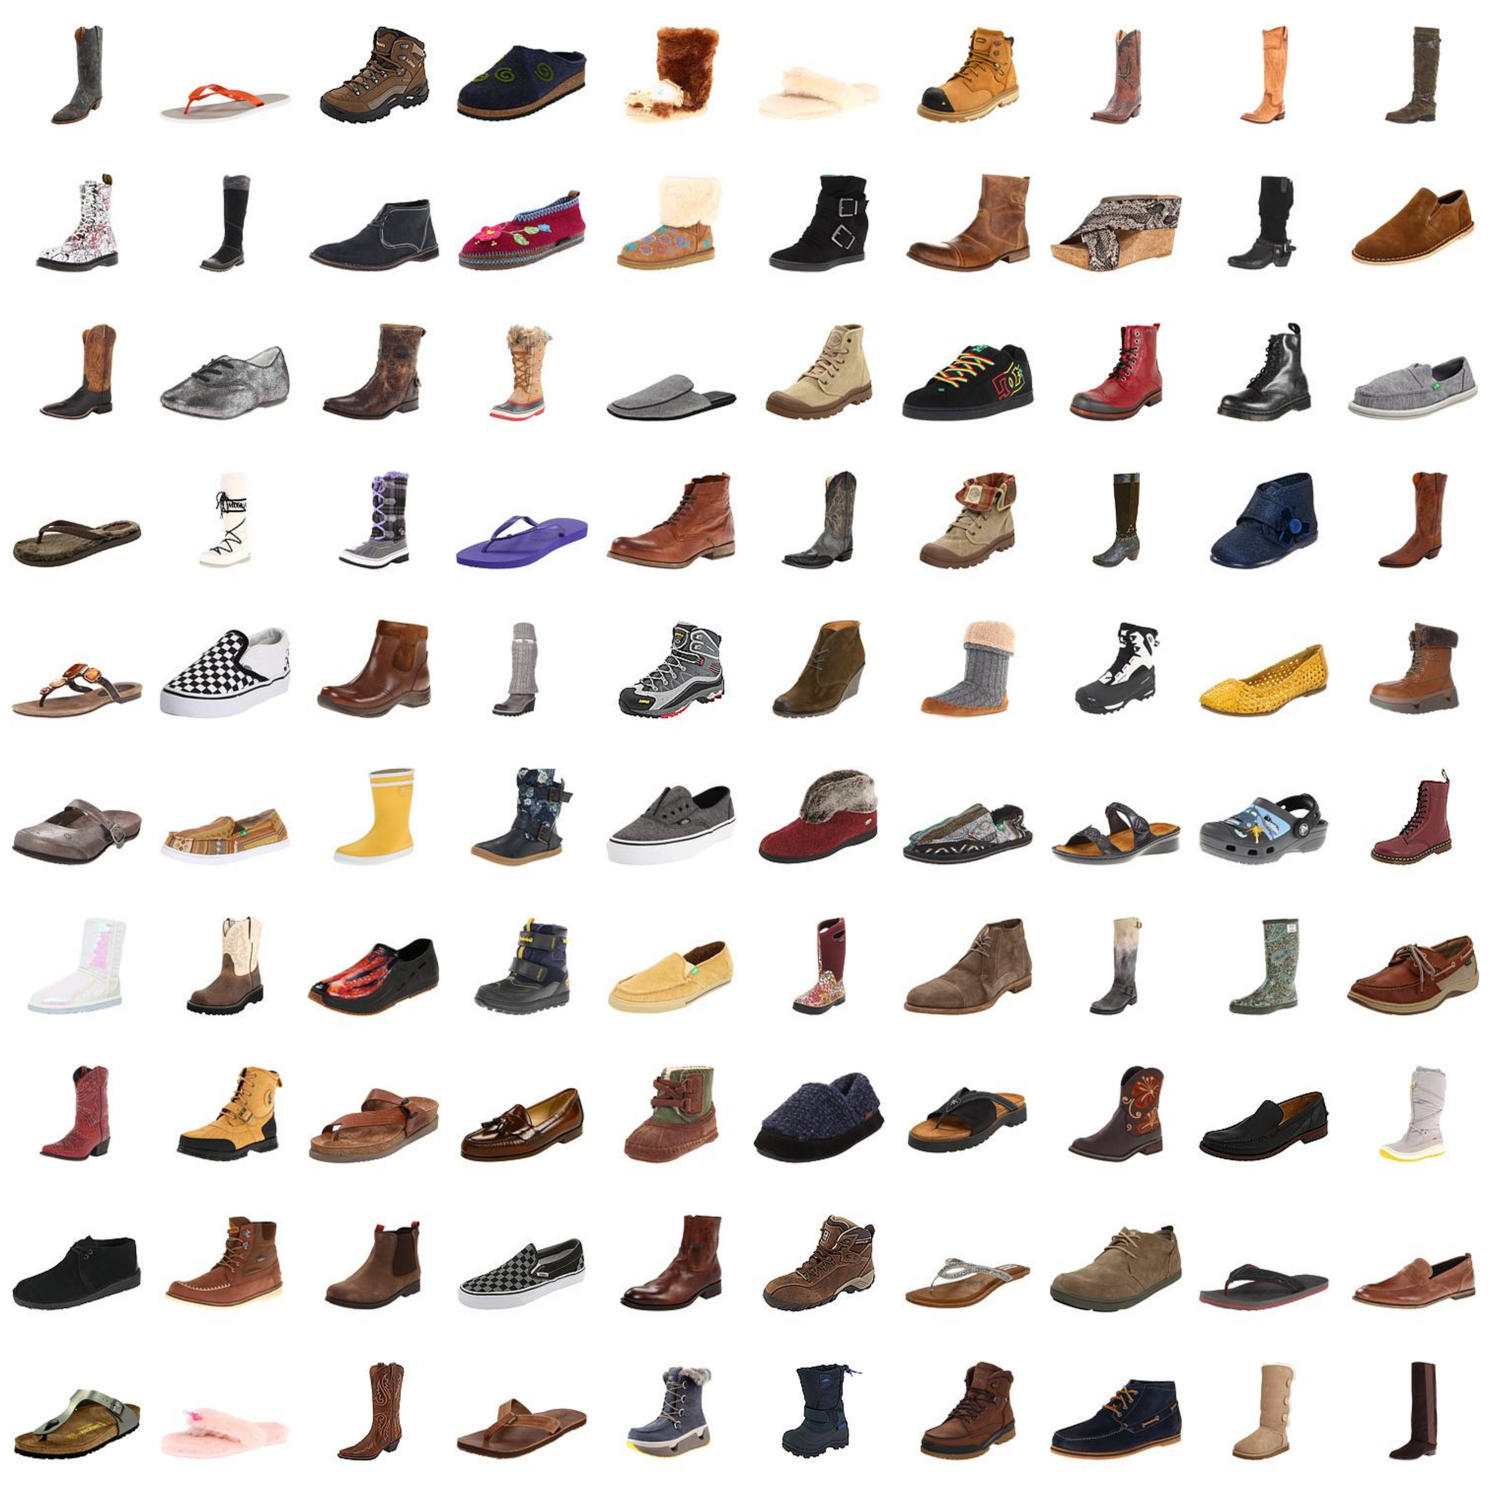

In [33]:
import matplotlib.pyplot as plt

# Get the first 100 indices from K[1]
indices = K[0][:100]

# Create a grid for displaying images
rows, cols = 10, 10  # 10x10 grid
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    img_index = indices[i]
    ax.imshow(sampled_images[img_index], cmap='gray')  # Remove cmap='gray' if images are RGB
    ax.axis('off')

plt.tight_layout()
plt.show()


(array([ 2.,  1.,  1.,  0.,  0.,  1.,  0.,  3.,  1.,  2.,  1.,  1.,  2.,
         2.,  1.,  2.,  3.,  6.,  3., 11.]),
 array([0.1328125 , 0.17617188, 0.21953125, 0.26289062, 0.30625   ,
        0.34960938, 0.39296875, 0.43632813, 0.4796875 , 0.52304687,
        0.56640625, 0.60976562, 0.653125  , 0.69648437, 0.73984375,
        0.78320312, 0.8265625 , 0.86992187, 0.91328125, 0.95664063,
        1.        ]),
 <BarContainer object of 20 artists>)

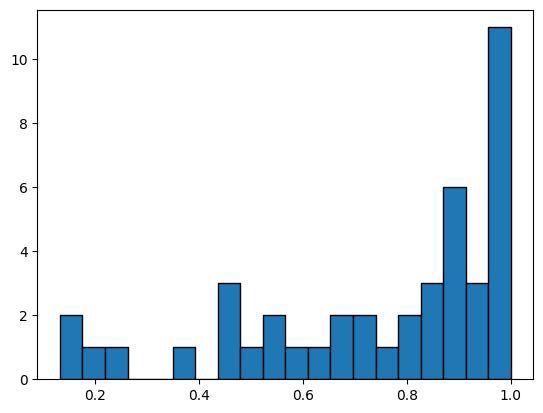

In [34]:
plt.hist(1-np.array(rank_list)/len(image_embeddings_tensor), bins=20, edgecolor='black')

In [35]:
from tqdm.notebook import tqdm

top_5 = 0
top_20 = 0
top_100 = 0
top_500 = 0

for i in tqdm(range(len(rank_list))):
    if rank_list[i] < 5:
        top_5 += 1/len(rank_list)
    if rank_list[i] < 20:
        top_20 += 1/len(rank_list)
    if rank_list[i] < 100:
        top_100 += 1/len(rank_list)
    if rank_list[i] < 500:
        top_500 += 1/len(rank_list)

  0%|          | 0/43 [00:00<?, ?it/s]

In [36]:
len(image_embeddings_tensor)

4096

In [37]:
len(rank_list)

43

In [38]:
median_rank = 1-np.median(rank_list)/len(image_embeddings_tensor)
mean_rank = 1-np.mean(rank_list)/len(image_embeddings_tensor)

In [39]:
print("Top 5:", top_5, "Top 20:", top_20, "Top 100:", top_100, "Top 500:", top_500)
print("Median rank", 1-np.median(rank_list)/len(image_embeddings_tensor))
print("Mean rank", 1-np.mean(rank_list)/len(image_embeddings_tensor))
print("Top quartile", 1-np.percentile(rank_list, 25)/len(image_embeddings_tensor))

Top 5: 0.023255813953488372 Top 20: 0.06976744186046512 Top 100: 0.16279069767441862 Top 500: 0.46511627906976727
Median rank 0.843505859375
Mean rank 0.7418638717296512
Top quartile 0.947509765625


In [40]:
from random import randint

25
Jack, a man of tradition and community, finds joy in planning, cooking, and hosting, his warmth making every gathering feel like a Southern Sunday afternoon.
1105


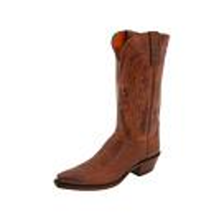

In [41]:
n = randint(0, len(test_personas) - 1)
print(n)
print(test_personas[n])
print(test_indices[n])
sampled_images[test_indices[n]]

In [42]:
sorted_indices

array([2057, 1587, 4018, ...,  776, 3703, 4007], dtype=int64)

Carmen, a 46-year-old air traffic control specialist, balances her high-stress job with creative outlets like painting and yoga, while her competitive nature and love for history shape her worldview


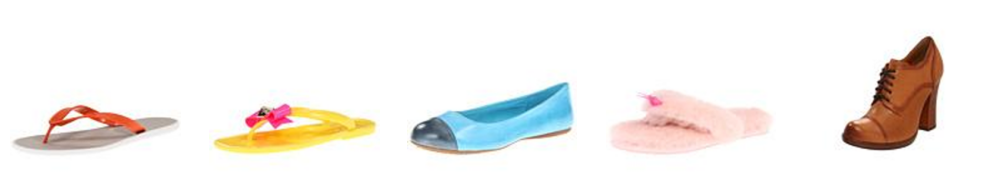

In [43]:
n = 1
print(test_personas[n])

stop_step = 0

img_list = [sampled_images[k] for k in K[n]]

num_images = 5
cols = 10  # images per row
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(cols * 2, rows * 2))  # adjust size as needed

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_list[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
with open(f'scores.json', 'r') as f:
    scores = json.load(f)
scores[image_set + "+" + text_set] = [median_rank, mean_rank, top_5, top_20, top_100, top_500]
with open(f'scores.json', 'w') as f:
    json.dump(scores, f)